# Rice Price Volatility — Preprocessing Pipeline
**Forecasting Rice Price Volatility in Sri Lanka Using Macroeconomic, Climate, and Fuel Cost Indicators**

This notebook implements the full preprocessing pipeline agreed on for `final_integrated_data.csv`:

1. Column pruning (keep / collapse / drop, per data audit)
2. Target definition (wholesale variety OR retail grain-class)
3. Date handling & resampling
4. Missing value treatment
5. Feature engineering (returns, volatility, lags, seasonal dummies)
6. Stationarity checks (ADF / KPSS)
7. Scaling (fit on train only — no leakage)
8. Chronological train/test split

Edit the **CONFIG** cell to switch between a wholesale-variety target and a retail grain-class target.


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)


## 1. Config

Choose your target here. This is the *only* cell you should need to edit to switch scope.

- `TARGET_MODE = "wholesale"` → target is a national wholesale variety price (e.g. `Nadu`, `Samba 1`, `Raw White`).
- `TARGET_MODE = "retail"` → target is a district-level grain-class retail price (e.g. `Kurunegala_Rice (medium grain)`).

Do **not** mix the two — wholesale prices are keyed by variety name, retail prices are keyed by grain class; they are correlated (~0.5–0.65) but not the same series (see data audit).


In [2]:
# ---- EDIT ME ----
TARGET_MODE = "wholesale"          # "wholesale" or "retail"
WHOLESALE_TARGET_COL = "Samba 2"      # used if TARGET_MODE == "wholesale"

RETAIL_DISTRICTS = ["Kurunegala", "Colombo City", "Anuradhapura"]  # used if TARGET_MODE == "retail"
RETAIL_GRAIN_CLASS = "medium grain"  # "long grain" | "medium grain" | "white" | "red" | "red nadu"

RESAMPLE_FREQ = "W"   # "D" for daily, "W" for weekly (recommended given irregular reporting gaps)
TEST_HORIZON_MONTHS = 15   # held-out period at the end of the series

RAW_PATH = "final_integrated_data.csv"


## 2. Load data

In [3]:
df = pd.read_csv(RAW_PATH)
df["Report_Date"] = pd.to_datetime(df["Report_Date"])
df = df.sort_values("Report_Date").drop_duplicates(subset="Report_Date").reset_index(drop=True)
print(df.shape)
df.head(3)


(2454, 240)


,Report_Date,Imported Rice,Keeri Samba,Nadu,Nadu 1,Nadu 2,Ponne Samba,Raw White,Raw red,Samba 1,Samba 2,Total_Production_MT,National_Yield_Efficiency,Season,Supply_YoY_Change_%,Exchange_Rate,Exchange_Rate_30d_PctChange,Rainfall_mm,Temp_Max_C,Temp_Min_C,Rainfall_14d_Cumulative,Is_Extreme_Heat,Ampara_Fuel (diesel),Ampara_Fuel (petrol-gasoline),Ampara_Rice (long grain),Ampara_Rice (medium grain),Ampara_Rice (white),Anuradhapura_Fuel (diesel),Anuradhapura_Fuel (petrol-gasoline),Anuradhapura_Rice (long grain),...,FAO_Insecticides_Organo_phosphates_Agricultural_Use_t,FAO_Insecticides_Pyrethroids_Agricultural_Use_t,FAO_Insecticides_nes_Agricultural_Use_t,FAO_Insecticides_â_Carbamates_Agricultural_Use_t,FAO_Insecticides_â_Chlorinated_Hydrocarbons_Agricultural_Use_t,FAO_Insecticides_â_Organo_phosphates_Agricultural_Use_t,FAO_Insecticides_â_Pyrethroids_Agricultural_Use_t,FAO_Pesticides_total_Agricultural_Use_t,FAO_Pesticides_total_Export_quantity_t,FAO_Pesticides_total_Export_value_1000_USD,FAO_Pesticides_total_Import_quantity_t,FAO_Pesticides_total_Import_value_1000_USD,FAO_Pesticides_total_Use_per_area_of_cropland_kg_ha,FAO_Pesticides_total_Use_per_capita_kg_cap,FAO_Pesticides_total_Use_per_value_of_agricultural_production_g_Int,FAO_Plant_Growth_Regulators_Agricultural_Use_t,FAO_Rodenticides_Agricultural_Use_t,FAO_Rodenticides_Anti_coagulants_Agricultural_Use_t,FAO_Rodenticides_â_Anti_coagulants_Agricultural_Use_t,CBSL_MonthlyWage_Paddy_Ploughing_with_Mammoties,CBSL_MonthlyWage_Paddy_Transplanting_and_Harvesting,CBSL_Producer_Price_Paddy_LKR,CBSL_Wage_Manuring,CBSL_Wage_Ploughing_with_Mammoties,CBSL_Wage_Ploughing_with_Ploughs,CBSL_Wage_Sowing,CBSL_Wage_Spraying,CBSL_Wage_Threshing,CBSL_Wage_Transplanting_and_Harvesting,CBSL_Wage_Winnowing
0,2015-08-07,NaN,NaN,NaN,62.4000,57.8,NaN,54.0,57.8,88.4,83.8,2611089.0,3.824432,2014-2015Maha,2629.152121,130.630005,0.145663,2.4,32.1,24.5,11.7,0.0,95.0,117.0,59.5,220.0,229.27,95.0,117.0,70.0,...,372.0,0.0,119.0,89.0,0.0,372.0,0.0,2540.0,433.288,1188.306,10771.221,65896.276,1.1,0.12,0.31,0.0,0.0,0.0,0.0,2356.0,1682.0,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0
1,2015-08-10,NaN,NaN,NaN,62.4000,57.6,NaN,54.0,57.6,89.2,82.4,2611089.0,3.824432,2014-2015Maha,2629.152121,130.630005,-0.045908,3.9,31.5,25.0,14.8,0.0,95.0,117.0,59.5,220.0,229.27,95.0,117.0,70.0,...,372.0,0.0,119.0,89.0,0.0,372.0,0.0,2540.0,433.288,1188.306,10771.221,65896.276,1.1,0.12,0.31,0.0,0.0,0.0,0.0,2356.0,1682.0,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0
2,2015-08-11,NaN,NaN,NaN,63.3334,56.6,NaN,52.8,58.6,88.6,83.8,2611089.0,3.824432,2014-2015Maha,2629.152121,130.570007,-0.267332,0.0,31.4,24.6,14.5,0.0,95.0,117.0,59.5,220.0,229.27,95.0,117.0,70.0,...,372.0,0.0,119.0,89.0,0.0,372.0,0.0,2540.0,433.288,1188.306,10771.221,65896.276,1.1,0.12,0.31,0.0,0.0,0.0,0.0,2356.0,1682.0,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0


## 3. Column pruning

Based on the data audit:

| Decision | Columns |
|---|---|
| **Keep as-is** | wholesale rice prices (minus 2 sparse ones), chosen retail grain-class columns, exchange rate + 30d change, climate block, national fuel (2 cols) |
| **Collapse** | 26×2 district fuel columns → `National Average_Fuel (diesel/petrol-gasoline)`; Season/Production/Yield → seasonal dummies, not raw levels |
| **Drop** | `Keeri Samba`, `Ponne Samba` (too sparse); 26 district fuel duplicates; ~70 FAO columns (annual, forward-filled → step function, low daily info); `CBSL_MonthlyWage_*` (only 3 unique values) |
| **Demote to static/annual control** | one derived FAO pesticide-intensity column, optionally CBSL wage/producer-price columns (annual step series) — used later only as slow trend features, not raw daily drivers |


In [4]:
# --- sparse wholesale columns: drop ---
sparse_wholesale = ["Keeri Samba", "Ponne Samba"]

# --- 26-district fuel duplicates: drop, keep national average only ---
district_fuel_cols = [c for c in df.columns if "_Fuel (diesel)" in c or "_Fuel (petrol-gasoline)" in c]
district_fuel_cols = [c for c in district_fuel_cols if not c.startswith("National Average")]

# --- FAO block: drop all but one derived intensity control ---
fao_cols = [c for c in df.columns if c.startswith("FAO_")]
fao_keep = ["FAO_Pesticides_total_Use_per_area_of_cropland_kg_ha"]
fao_drop = [c for c in fao_cols if c not in fao_keep]

# --- CBSL: drop sparse monthly wage series, keep the rest as annual controls ---
cbsl_monthlywage_cols = [c for c in df.columns if c.startswith("CBSL_MonthlyWage_")]

drop_cols = sparse_wholesale + district_fuel_cols + fao_drop + cbsl_monthlywage_cols
drop_cols = [c for c in drop_cols if c in df.columns]

print(f"Dropping {len(drop_cols)} columns "
      f"({len(sparse_wholesale)} sparse wholesale, {len(district_fuel_cols)} duplicate fuel, "
      f"{len(fao_drop)} FAO, {len(cbsl_monthlywage_cols)} CBSL monthly-wage)")

df_pruned = df.drop(columns=drop_cols)
print("Remaining columns:", df_pruned.shape[1])


Dropping 103 columns (2 sparse wholesale, 50 duplicate fuel, 49 FAO, 2 CBSL monthly-wage)
Remaining columns: 137


### 3.1 Keep only the retail columns for the districts we actually need

Drops the other ~35 locations' retail columns to avoid a wide, mostly-irrelevant feature set.

In [5]:
all_retail_cols = [c for c in df_pruned.columns if "_Rice (" in c]

if TARGET_MODE == "retail":
    keep_retail_cols = [c for d in RETAIL_DISTRICTS for c in all_retail_cols if c.startswith(d + "_Rice")]
else:
    # still keep a small retail panel as covariates even in wholesale mode (optional, comment out to exclude)
    keep_retail_cols = [c for d in RETAIL_DISTRICTS for c in all_retail_cols if c.startswith(d + "_Rice")]

drop_retail_cols = [c for c in all_retail_cols if c not in keep_retail_cols]
df_pruned = df_pruned.drop(columns=drop_retail_cols)
print(f"Kept {len(keep_retail_cols)} retail columns for districts: {RETAIL_DISTRICTS}")
df_pruned.columns.tolist()


Kept 9 retail columns for districts: ['Kurunegala', 'Colombo City', 'Anuradhapura']


['Report_Date',
 'Imported Rice',
 'Nadu',
 'Nadu 1',
 'Nadu 2',
 'Raw White',
 'Raw red',
 'Samba 1',
 'Samba 2',
 'Total_Production_MT',
 'National_Yield_Efficiency',
 'Season',
 'Supply_YoY_Change_%',
 'Exchange_Rate',
 'Exchange_Rate_30d_PctChange',
 'Rainfall_mm',
 'Temp_Max_C',
 'Temp_Min_C',
 'Rainfall_14d_Cumulative',
 'Is_Extreme_Heat',
 'Anuradhapura_Rice (long grain)',
 'Anuradhapura_Rice (medium grain)',
 'Anuradhapura_Rice (white)',
 'Colombo City_Rice (long grain)',
 'Colombo City_Rice (medium grain)',
 'Colombo City_Rice (white)',
 'Kurunegala_Rice (long grain)',
 'Kurunegala_Rice (medium grain)',
 'Kurunegala_Rice (white)',
 'National Average_Fuel (diesel)',
 'National Average_Fuel (petrol-gasoline)',
 'FAO_Pesticides_total_Use_per_area_of_cropland_kg_ha',
 'CBSL_Producer_Price_Paddy_LKR',
 'CBSL_Wage_Manuring',
 'CBSL_Wage_Ploughing_with_Mammoties',
 'CBSL_Wage_Ploughing_with_Ploughs',
 'CBSL_Wage_Sowing',
 'CBSL_Wage_Spraying',
 'CBSL_Wage_Threshing',
 'CBSL_Wage_Tran

## 4. Target definition

Target column: Samba 2


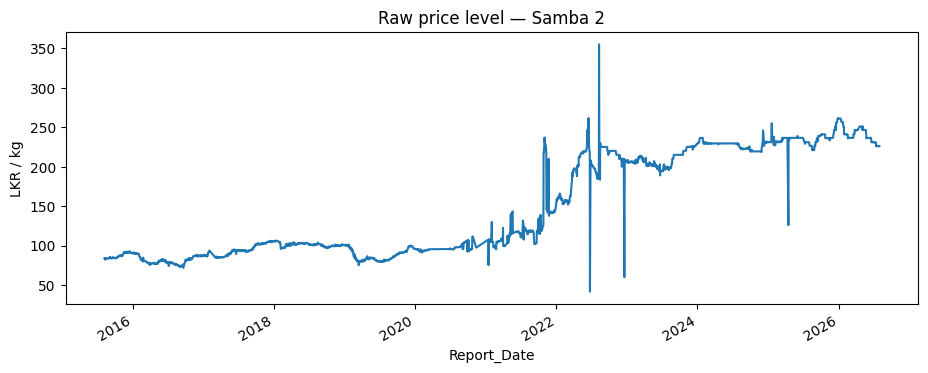

In [6]:
if TARGET_MODE == "wholesale":
    target_col = WHOLESALE_TARGET_COL
    assert target_col in df_pruned.columns, f"{target_col} not found"
else:
    target_col = f"{RETAIL_DISTRICTS[0]}_Rice ({RETAIL_GRAIN_CLASS})"
    assert target_col in df_pruned.columns, f"{target_col} not found"

print("Target column:", target_col)
df_pruned[["Report_Date", target_col]].set_index("Report_Date")[target_col].plot(title=f"Raw price level — {target_col}")
plt.ylabel("LKR / kg")
plt.show()


## 5. Date handling & resampling

Reporting gaps are irregular (1–7 days, occasional longer gaps). We resample to a
consistent frequency:
- Price / macro columns → `mean` (or `last`) within each period
- Slow-moving annual/seasonal columns → `ffill` after resampling (they don't need aggregation, just alignment)


In [7]:
df_idx = df_pruned.set_index("Report_Date")

# classify columns by how they should be aggregated on resample
seasonal_step_cols = ["Total_Production_MT", "National_Yield_Efficiency", "Season", "Supply_YoY_Change_%"]
annual_step_cols = [c for c in df_idx.columns if c.startswith("CBSL_") or c.startswith("FAO_")]
price_like_cols = [c for c in df_idx.columns if c not in seasonal_step_cols + annual_step_cols]

agg_dict = {c: "mean" for c in price_like_cols if pd.api.types.is_numeric_dtype(df_idx[c])}
agg_dict.update({c: "last" for c in seasonal_step_cols + annual_step_cols if c in df_idx.columns})
# Season is categorical -> last
if "Season" in agg_dict:
    agg_dict["Season"] = "last"

df_res = df_idx.resample(RESAMPLE_FREQ).agg(agg_dict)
print("Resampled shape:", df_res.shape)
df_res.head(3)


Resampled shape: (574, 40)


,Imported Rice,Nadu,Nadu 1,Nadu 2,Raw White,Raw red,Samba 1,Samba 2,Exchange_Rate,Exchange_Rate_30d_PctChange,Rainfall_mm,Temp_Max_C,Temp_Min_C,Rainfall_14d_Cumulative,Is_Extreme_Heat,Anuradhapura_Rice (long grain),Anuradhapura_Rice (medium grain),Anuradhapura_Rice (white),Colombo City_Rice (long grain),Colombo City_Rice (medium grain),Colombo City_Rice (white),Kurunegala_Rice (long grain),Kurunegala_Rice (medium grain),Kurunegala_Rice (white),National Average_Fuel (diesel),National Average_Fuel (petrol-gasoline),Total_Production_MT,National_Yield_Efficiency,Season,Supply_YoY_Change_%,FAO_Pesticides_total_Use_per_area_of_cropland_kg_ha,CBSL_Producer_Price_Paddy_LKR,CBSL_Wage_Manuring,CBSL_Wage_Ploughing_with_Mammoties,CBSL_Wage_Ploughing_with_Ploughs,CBSL_Wage_Sowing,CBSL_Wage_Spraying,CBSL_Wage_Threshing,CBSL_Wage_Transplanting_and_Harvesting,CBSL_Wage_Winnowing
Report_Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-08-09,NaN,NaN,62.40000,57.80,54.00,57.80,88.40,83.8,130.630005,0.145663,2.40,32.10,24.50,11.70,0.0,70.00,215.5,230.0,68.75,217.79,68.64,64.60,211.17,230.0,95.0,117.0,2611089.0,3.824432,2014-2015Maha,2629.152121,1.1,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0
2015-08-16,NaN,NaN,62.50668,57.92,54.44,57.76,88.92,83.4,130.658005,-0.080999,1.48,32.36,24.74,15.10,0.0,70.00,215.5,230.0,68.75,217.79,68.64,64.60,211.17,230.0,95.0,117.0,2611089.0,3.824432,2014-2015Maha,2629.152121,1.1,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0
2015-08-23,NaN,NaN,64.12500,61.00,56.80,58.40,89.30,83.7,130.404999,-0.286741,0.95,31.80,24.65,58.35,0.0,58.62,215.5,230.0,67.22,217.79,64.88,69.24,211.17,230.0,95.0,117.0,2611089.0,3.824432,2014-2015Maha,2629.152121,1.1,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0


## 6. Missing value treatment

In [8]:
miss_before = df_res.isna().mean().sort_values(ascending=False)
print("Top missing (post-resample):")
print(miss_before[miss_before > 0].head(15))


Top missing (post-resample):
Imported Rice                              0.412892
Nadu                                       0.355401
Nadu 1                                     0.127178
Colombo City_Rice (medium grain)           0.125436
Colombo City_Rice (white)                  0.125436
Kurunegala_Rice (long grain)               0.125436
Kurunegala_Rice (medium grain)             0.125436
Anuradhapura_Rice (long grain)             0.125436
Kurunegala_Rice (white)                    0.125436
National Average_Fuel (diesel)             0.125436
National Average_Fuel (petrol-gasoline)    0.125436
Anuradhapura_Rice (medium grain)           0.125436
Anuradhapura_Rice (white)                  0.125436
Colombo City_Rice (long grain)             0.125436
Samba 1                                    0.081882
dtype: float64


In [9]:
# Price-like columns: short-gap linear interpolation, cap at 5 periods
interp_cols = [c for c in price_like_cols if c in df_res.columns]
df_res[interp_cols] = df_res[interp_cols].interpolate(method="linear", limit=5, limit_direction="both")

# Seasonal/annual step columns: forward-fill (then back-fill only at the very start of the series)
step_cols = [c for c in seasonal_step_cols + annual_step_cols if c in df_res.columns]
df_res[step_cols] = df_res[step_cols].ffill().bfill()

remaining_na = df_res.isna().sum()
remaining_na = remaining_na[remaining_na > 0]
print("Columns still with NA after treatment:", len(remaining_na))
print(remaining_na)


Columns still with NA after treatment: 26
Imported Rice                              167
Nadu                                       146
Nadu 1                                       6
Nadu 2                                       3
Raw White                                    3
Raw red                                      3
Samba 1                                      4
Samba 2                                      3
Exchange_Rate                                3
Exchange_Rate_30d_PctChange                  3
Rainfall_mm                                  3
Temp_Max_C                                   3
Temp_Min_C                                   3
Rainfall_14d_Cumulative                      3
Is_Extreme_Heat                              3
Anuradhapura_Rice (long grain)              43
Anuradhapura_Rice (medium grain)            43
Anuradhapura_Rice (white)                   43
Colombo City_Rice (long grain)              43
Colombo City_Rice (medium grain)            43
Colombo City_Rice 

In [10]:
# If the target itself still has leading NA (e.g. reporting started later), trim the frame to start
# at the first valid target observation rather than imputing a long leading gap.
first_valid = df_res[target_col].first_valid_index()
print("First valid target date:", first_valid)
df_res = df_res.loc[first_valid:]
df_res = df_res.dropna(subset=[target_col])
print("Shape after trimming to target availability:", df_res.shape)


First valid target date: 2015-08-09 00:00:00
Shape after trimming to target availability: (571, 40)


## 7. Feature engineering

- Log returns + rolling volatility of the **target** (this is the actual quantity of interest for a *volatility* forecasting project — not the raw price level)
- Log-difference / % change transforms for exchange rate and fuel (stationarity)
- Rolling volatility windows as features
- Seasonal one-hot dummy from `Season` (categorical Maha/Yala) instead of raw production level
- Lag features for target and exchange rate


In [11]:
eps = 1e-6

# --- Target: log price, log return, rolling volatility ---
df_feat = df_res.copy()
df_feat["log_price"] = np.log(df_feat[target_col] + eps)
df_feat["log_return"] = df_feat["log_price"].diff()

for w in [4, 8, 12]:  # ~1, 2, 3 months of weekly data
    df_feat[f"volatility_{w}p"] = df_feat["log_return"].rolling(w).std()

# primary volatility target (choose the horizon that matches your forecasting objective)
df_feat["target_volatility"] = df_feat["volatility_4p"]


In [12]:
# --- Macro / cost-side stationarity transforms ---
for col in ["Exchange_Rate", "National Average_Fuel (diesel)", "National Average_Fuel (petrol-gasoline)"]:
    if col in df_feat.columns:
        df_feat[f"{col}_logret"] = np.log(df_feat[col] + eps).diff()

# Exchange_Rate_30d_PctChange already exists as a raw feature — keep it, it's already a change measure.


In [13]:
# --- Seasonal dummy instead of raw production level ---
if "Season" in df_feat.columns:
    season_type = df_feat["Season"].str.extract(r"(Maha|Yala)")[0]
    season_dummies = pd.get_dummies(season_type, prefix="season", drop_first=True)
    df_feat = pd.concat([df_feat, season_dummies], axis=1)

# National_Yield_Efficiency / Total_Production_MT / Supply_YoY_Change_% are kept only as slow-moving
# controls (already forward-filled); do NOT expect them to explain short-run volatility.


In [14]:
# --- Lag features ---
lag_source_cols = ["log_price", "log_return"]
if "Exchange_Rate" in df_feat.columns:
    lag_source_cols.append("Exchange_Rate")

for col in lag_source_cols:
    for lag in [1, 2, 4]:
        df_feat[f"{col}_lag{lag}"] = df_feat[col].shift(lag)

df_feat.head(3)


,Imported Rice,Nadu,Nadu 1,Nadu 2,Raw White,Raw red,Samba 1,Samba 2,Exchange_Rate,Exchange_Rate_30d_PctChange,Rainfall_mm,Temp_Max_C,Temp_Min_C,Rainfall_14d_Cumulative,Is_Extreme_Heat,Anuradhapura_Rice (long grain),Anuradhapura_Rice (medium grain),Anuradhapura_Rice (white),Colombo City_Rice (long grain),Colombo City_Rice (medium grain),Colombo City_Rice (white),Kurunegala_Rice (long grain),Kurunegala_Rice (medium grain),Kurunegala_Rice (white),National Average_Fuel (diesel),National Average_Fuel (petrol-gasoline),Total_Production_MT,National_Yield_Efficiency,Season,Supply_YoY_Change_%,FAO_Pesticides_total_Use_per_area_of_cropland_kg_ha,CBSL_Producer_Price_Paddy_LKR,CBSL_Wage_Manuring,CBSL_Wage_Ploughing_with_Mammoties,CBSL_Wage_Ploughing_with_Ploughs,CBSL_Wage_Sowing,CBSL_Wage_Spraying,CBSL_Wage_Threshing,CBSL_Wage_Transplanting_and_Harvesting,CBSL_Wage_Winnowing,log_price,log_return,volatility_4p,volatility_8p,volatility_12p,target_volatility,Exchange_Rate_logret,National Average_Fuel (diesel)_logret,National Average_Fuel (petrol-gasoline)_logret,season_Yala,log_price_lag1,log_price_lag2,log_price_lag4,log_return_lag1,log_return_lag2,log_return_lag4,Exchange_Rate_lag1,Exchange_Rate_lag2,Exchange_Rate_lag4
Report_Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-08-09,NaN,NaN,62.40000,57.80,54.00,57.80,88.40,83.8,130.630005,0.145663,2.40,32.10,24.50,11.70,0.0,70.00,215.5,230.0,68.75,217.79,68.64,64.60,211.17,230.0,95.0,117.0,2611089.0,3.824432,2014-2015Maha,2629.152121,1.1,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0,4.428433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-08-16,NaN,NaN,62.50668,57.92,54.44,57.76,88.92,83.4,130.658005,-0.080999,1.48,32.36,24.74,15.10,0.0,70.00,215.5,230.0,68.75,217.79,68.64,64.60,211.17,230.0,95.0,117.0,2611089.0,3.824432,2014-2015Maha,2629.152121,1.1,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0,4.423648,-0.004785,NaN,NaN,NaN,NaN,0.000214,0.0,0.0,False,4.428433,NaN,NaN,NaN,NaN,NaN,130.630005,NaN,NaN
2015-08-23,NaN,NaN,64.12500,61.00,56.80,58.40,89.30,83.7,130.404999,-0.286741,0.95,31.80,24.65,58.35,0.0,58.62,215.5,230.0,67.22,217.79,64.88,69.24,211.17,230.0,95.0,117.0,2611089.0,3.824432,2014-2015Maha,2629.152121,1.1,41.12,1012.0,1045.0,1129.0,1041.0,1172.0,1077.0,970.0,1019.0,4.427239,0.003591,NaN,NaN,NaN,NaN,-0.001938,0.0,0.0,False,4.423648,4.428433,NaN,-0.004785,NaN,NaN,130.658005,130.630005,NaN


## 8. Stationarity checks (ADF / KPSS)

Run on the raw target level vs. the log-return series to confirm the transform is needed.


In [15]:
def stationarity_report(series, name):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series)
    kpss_stat, kpss_p, *_ = kpss(series, nlags="auto")
    print(f"--- {name} ---")
    print(f"ADF:  stat={adf_stat:.3f}  p={adf_p:.4f}  -> {'stationary' if adf_p < 0.05 else 'NON-stationary'}")
    print(f"KPSS: stat={kpss_stat:.3f}  p={kpss_p:.4f}  -> {'stationary' if kpss_p > 0.05 else 'NON-stationary'}")
    print()

stationarity_report(df_feat[target_col], f"{target_col} (raw level)")
stationarity_report(df_feat["log_return"], f"{target_col} (log return)")


--- Samba 2 (raw level) ---
ADF:  stat=-0.453  p=0.9009  -> NON-stationary
KPSS: stat=3.110  p=0.0100  -> NON-stationary

--- Samba 2 (log return) ---
ADF:  stat=-11.966  p=0.0000  -> stationary
KPSS: stat=0.100  p=0.1000  -> stationary



## 9. Scaling

Fit the scaler on the **training split only** to avoid leakage, then transform both splits.


In [16]:
feature_cols = [c for c in df_feat.columns if c not in
                ["Report_Date", target_col, "target_volatility", "Season"]]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_feat[c])]

df_model = df_feat.dropna(subset=["target_volatility"]).copy()
print("Modeling frame shape:", df_model.shape)


Modeling frame shape: (567, 59)


## 10. Chronological train/test split

In [17]:
split_date = df_model.index.max() - pd.DateOffset(months=TEST_HORIZON_MONTHS)
train = df_model.loc[:split_date]
test = df_model.loc[split_date:]

print(f"Split date: {split_date.date()}")
print(f"Train: {train.shape[0]} rows ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {test.shape[0]} rows ({test.index.min().date()} -> {test.index.max().date()})")


Split date: 2025-05-02
Train: 501 rows (2015-09-06 -> 2025-04-27)
Test:  66 rows (2025-05-04 -> 2026-08-02)


In [18]:
scaler = StandardScaler()
X_train = train[feature_cols].fillna(0)
X_test = test[feature_cols].fillna(0)

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=train.index, columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=test.index, columns=feature_cols)

y_train = train["target_volatility"]
y_test = test["target_volatility"]

print(X_train_scaled.shape, X_test_scaled.shape)
X_train_scaled.head(3)


(501, 56) (66, 56)


,Imported Rice,Nadu,Nadu 1,Nadu 2,Raw White,Raw red,Samba 1,Exchange_Rate,Exchange_Rate_30d_PctChange,Rainfall_mm,Temp_Max_C,Temp_Min_C,Rainfall_14d_Cumulative,Is_Extreme_Heat,Anuradhapura_Rice (long grain),Anuradhapura_Rice (medium grain),Anuradhapura_Rice (white),Colombo City_Rice (long grain),Colombo City_Rice (medium grain),Colombo City_Rice (white),Kurunegala_Rice (long grain),Kurunegala_Rice (medium grain),Kurunegala_Rice (white),National Average_Fuel (diesel),National Average_Fuel (petrol-gasoline),Total_Production_MT,National_Yield_Efficiency,Supply_YoY_Change_%,FAO_Pesticides_total_Use_per_area_of_cropland_kg_ha,CBSL_Producer_Price_Paddy_LKR,CBSL_Wage_Manuring,CBSL_Wage_Ploughing_with_Mammoties,CBSL_Wage_Ploughing_with_Ploughs,CBSL_Wage_Sowing,CBSL_Wage_Spraying,CBSL_Wage_Threshing,CBSL_Wage_Transplanting_and_Harvesting,CBSL_Wage_Winnowing,log_price,log_return,volatility_4p,volatility_8p,volatility_12p,Exchange_Rate_logret,National Average_Fuel (diesel)_logret,National Average_Fuel (petrol-gasoline)_logret,season_Yala,log_price_lag1,log_price_lag2,log_price_lag4,log_return_lag1,log_return_lag2,log_return_lag4,Exchange_Rate_lag1,Exchange_Rate_lag2,Exchange_Rate_lag4
Report_Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-09-06,-1.010206,-0.865467,-1.015962,-0.856365,-0.888755,-0.886667,-0.905029,-1.138892,-0.071172,0.174301,1.458126,1.262942,-0.668101,-0.167754,-3.468147,-0.328179,-0.37076,-3.169183,-0.347362,-1.030522,-2.267032,-0.405438,-0.386869,0.0,0.0,-1.179603,0.462407,1.628696,0.43999,-0.927593,-1.389493,-1.26844,-1.236174,-1.301554,-1.251646,-1.378802,-1.298477,-1.2406,-0.992283,0.178869,-0.392143,-0.703072,-0.782251,0.235320,0.0,0.0,0.970495,-1.013315,-1.003973,-0.993661,-0.086349,0.036759,-0.050404,-1.142537,-1.147236,-1.135041
2015-09-13,-1.010206,-0.865467,-1.003619,-0.853548,-0.888105,-0.890145,-0.894707,-1.089375,0.294751,-0.308044,0.087159,0.966623,0.028657,-0.167754,-3.468147,-0.328179,-0.37076,-3.169183,-0.347362,-1.030522,-2.267032,-0.405438,-0.386869,0.0,0.0,-1.179603,0.462407,1.628696,0.43999,-0.927593,-1.389493,-1.26844,-1.236174,-1.301554,-1.251646,-1.378802,-1.298477,-1.2406,-0.986717,0.003995,-0.432290,-0.703072,-0.782251,1.998107,0.0,0.0,0.970495,-0.988524,-1.009306,-1.005547,0.197817,-0.103039,-0.166861,-1.134280,-1.137898,-1.134667
2015-09-20,-1.010206,-0.865467,-1.034187,-0.851098,-0.889497,-0.887469,-0.898869,-1.068729,0.488906,-0.543122,0.271760,1.216762,0.027559,-0.167754,-3.378090,-0.328179,-0.37076,-2.784928,-0.347362,-1.042451,-2.276601,-0.405438,-0.386869,0.0,0.0,-1.179603,0.462407,1.628696,0.43999,-0.927593,-1.389493,-1.26844,-1.236174,-1.301554,-1.251646,-1.378802,-1.298477,-1.2406,-0.998449,-0.153619,-0.395031,-0.703072,-0.782251,0.743422,0.0,0.0,0.970495,-0.982951,-0.984519,-0.996627,0.016534,0.192938,0.036991,-1.084771,-1.129643,-1.138045


## 11. Save processed outputs

In [19]:
train_out = X_train_scaled.copy()
train_out["target_volatility"] = y_train
train_out["raw_price"] = train[target_col]

test_out = X_test_scaled.copy()
test_out["target_volatility"] = y_test
test_out["raw_price"] = test[target_col]

train_out.to_csv("processed_train.csv")
test_out.to_csv("processed_test.csv")
df_feat.to_csv("processed_full_features.csv")

print("Saved: processed_train.csv, processed_test.csv, processed_full_features.csv")


Saved: processed_train.csv, processed_test.csv, processed_full_features.csv


## Notes / next steps
- If `ADF`/`KPSS` on `log_return` still indicate non-stationarity, try a second difference or a GARCH-family model directly on `log_return` instead of a rolling-std proxy.
- `target_volatility` currently uses a 4-period (≈1 month at weekly resolution) rolling std — change `volatility_4p` to `volatility_8p`/`volatility_12p` in the config/feature step if your project defines volatility over a longer horizon.
- The retail covariate columns (`RETAIL_DISTRICTS`) are included as **features** even in wholesale mode, since district retail prices can lead/lag the national wholesale series — drop them if you want a purely macro/climate/fuel model.
- FAO and CBSL annual columns are intentionally left as slow step-controls, not daily drivers — don't expect them to carry weight in short-horizon volatility models; consider them only for a long-run trend narrative in your discussion section.
